In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
data =pd.read_csv(r"C:\DATA ANALYTICS\PRACTICE DATA\ecommerce_raw_messy_250400.csv",encoding='latin-1')


In [82]:
data.head()

,Order ID,Order Date,Customer ID,Customer Name,Product ID,Product / Product Name,Category,Quantity,Sales / Revenue,Cost,Profit,Discount,City,State,Region
0,ORD1013864,2023-09-19,C32905,Priya Malhotra,P7002,Programming Book,Books,3,2157.60,1170.0,987.60,0.20,Nagpur,Maharashtra,West
1,ORD1041955,2026-03-01,C35163,Aarav Mehta,P3007,Electric Kettle,Home & Kitchen,1,1279.20,850.0,429.20,0.20,Panipat,Haryana,North
2,ORD1233639,2025-06-27,C02431,Priya Verma,P6004,Dumbbell Set,Sports,1,2699.10,1650.0,1049.10,0.10,Hubli,Karnataka,South
3,ORD1137427,2025-08-14,C21240,Arjun Pal,P1001,Wireless Mouse,Electronics,1,459.08,280.0,179.08,0.08,Mumbai,Maharashtra,West
4,ORD1131749,2025-10-04,C21640,Vikas Verma,P5004,Desk Organizer,Stationery,2,848.30,440.0,408.30,0.15,Nizamabad,Telangana,South


In [83]:
data.describe()

,Quantity,Sales / Revenue,Cost,Profit,Discount
count,250400.000000,250400.000000,249639.000000,249639.000000,249899.000000
mean,2.135284,3652.111751,2233.470331,1417.560996,0.087764
std,1.532904,5522.329340,3901.223667,1760.471740,0.072952
min,0.000000,139.300000,70.000000,69.300000,0.000000
25%,1.000000,957.600000,480.000000,449.100000,0.030000
50%,2.000000,1998.000000,1080.000000,874.050000,0.080000
75%,3.000000,4197.200000,2500.000000,1718.100000,0.100000
max,10.000000,109990.000000,76000.000000,33990.000000,0.500000


In [84]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250400 entries, 0 to 250399
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Order ID                250400 non-null  str    
 1   Order Date              250400 non-null  str    
 2   Customer ID             250400 non-null  str    
 3   Customer Name           249396 non-null  str    
 4   Product ID              250400 non-null  str    
 5   Product / Product Name  250400 non-null  str    
 6   Category                250400 non-null  str    
 7   Quantity                250400 non-null  int64  
 8   Sales / Revenue         250400 non-null  float64
 9   Cost                    249639 non-null  float64
 10  Profit                  249639 non-null  float64
 11  Discount                249899 non-null  float64
 12  City                    249652 non-null  str    
 13  State                   250400 non-null  str    
 14  Region                  250400 

 # Change date from string to date format
 

In [85]:
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250400 entries, 0 to 250399
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Order ID                250400 non-null  str           
 1   Order Date              249119 non-null  datetime64[us]
 2   Customer ID             250400 non-null  str           
 3   Customer Name           249396 non-null  str           
 4   Product ID              250400 non-null  str           
 5   Product / Product Name  250400 non-null  str           
 6   Category                250400 non-null  str           
 7   Quantity                250400 non-null  int64         
 8   Sales / Revenue         250400 non-null  float64       
 9   Cost                    249639 non-null  float64       
 10  Profit                  249639 non-null  float64       
 11  Discount                249899 non-null  float64       
 12  City                    249652 non-null  

In [86]:
data.isnull().sum()

Order ID                     0
Order Date                1281
Customer ID                  0
Customer Name             1004
Product ID                   0
Product / Product Name       0
Category                     0
Quantity                     0
Sales / Revenue              0
Cost                       761
Profit                     761
Discount                   501
City                       748
State                        0
Region                       0
dtype: int64

In [87]:
data.duplicated().sum()

np.int64(400)

In [88]:
data['order month'] = data['Order Date'].dt.month.astype('Int64')
data['order year'] = data['Order Date'].dt.year.astype('Int64')


# Monthly Sales

In [89]:
sales_by_month =data.groupby('order month')['Sales / Revenue'].sum().reset_index()
sales_by_month

,order month,Sales / Revenue
0,1,8.251210e+07
1,2,7.383434e+07
2,3,8.136517e+07
3,4,7.946645e+07
4,5,8.150695e+07
5,6,8.085701e+07
6,7,8.307566e+07
7,8,8.391627e+07
8,9,7.827498e+07
9,10,6.257454e+07


Text(0.5, 1.0, 'Sales Analysis')

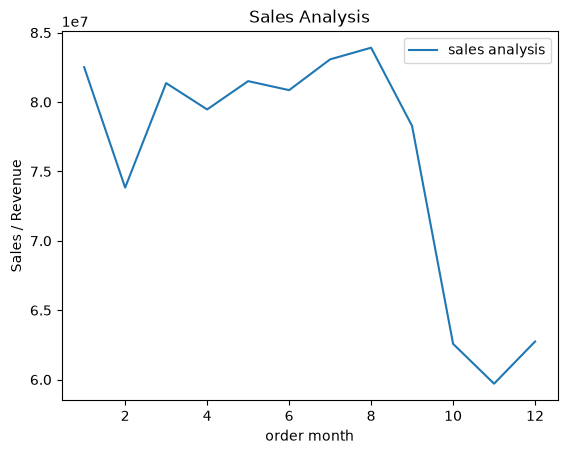

In [90]:
fig =sns.lineplot(sales_by_month,
             x='order month', 
             y = 'Sales / Revenue',
             label='sales analysis')
fig.set_title('Sales Analysis')

# Sales by category

In [91]:
sales_by_category = data.groupby('Category')['Sales / Revenue'].sum().reset_index()
sales_by_category

,Category,Sales / Revenue
0,Beauty,5.347427e+07
1,Books,2.398866e+07
2,Electronics,3.171094e+08
3,Fashion,1.582292e+08
4,Home & Kitchen,1.809740e+08
5,Sports,8.426098e+07
6,Stationery,9.645229e+07


C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\2612154413.py:2: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  bar = sns.barplot(sales_by_category,


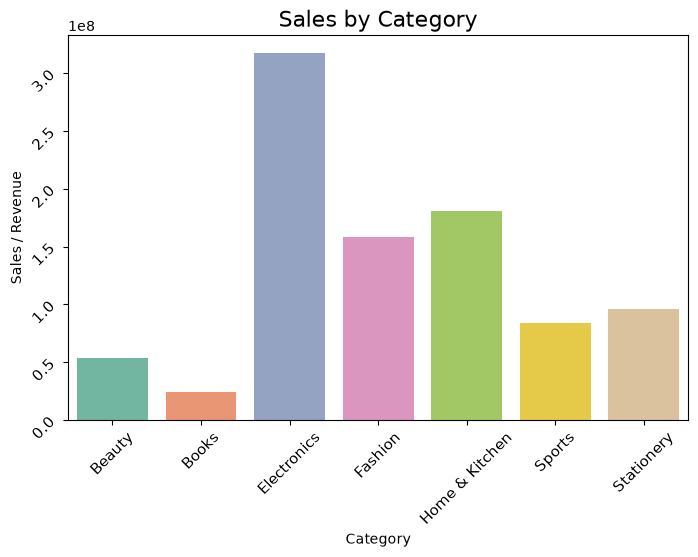

In [92]:
plt.figure(figsize = (8, 5))
bar = sns.barplot(sales_by_category,
                  x='Category',
                  y='Sales / Revenue',
                  hue='Category',
                  palette=sns.color_palette("Set2"))

bar.set_title('Sales by Category', fontsize=16)
bar.tick_params(labelsize=11, rotation=45)


plt.show()

# Sales analysis by product name


In [93]:
data.head()

,Order ID,Order Date,Customer ID,Customer Name,Product ID,Product / Product Name,Category,Quantity,Sales / Revenue,Cost,Profit,Discount,City,State,Region,order month,order year
0,ORD1013864,2023-09-19,C32905,Priya Malhotra,P7002,Programming Book,Books,3,2157.60,1170.0,987.60,0.20,Nagpur,Maharashtra,West,9,2023
1,ORD1041955,2026-03-01,C35163,Aarav Mehta,P3007,Electric Kettle,Home & Kitchen,1,1279.20,850.0,429.20,0.20,Panipat,Haryana,North,3,2026
2,ORD1233639,2025-06-27,C02431,Priya Verma,P6004,Dumbbell Set,Sports,1,2699.10,1650.0,1049.10,0.10,Hubli,Karnataka,South,6,2025
3,ORD1137427,2025-08-14,C21240,Arjun Pal,P1001,Wireless Mouse,Electronics,1,459.08,280.0,179.08,0.08,Mumbai,Maharashtra,West,8,2025
4,ORD1131749,2025-10-04,C21640,Vikas Verma,P5004,Desk Organizer,Stationery,2,848.30,440.0,408.30,0.15,Nizamabad,Telangana,South,10,2025


In [94]:
sales_by_product = data.groupby('Product / Product Name')['Sales / Revenue'].sum().reset_index()
sales_by_product

,Product / Product Name,Sales / Revenue
0,Air Fryer,7.179345e+07
1,Backpack,1.724028e+07
2,Bedsheet Set,1.423824e+07
3,Bluetooth Speaker,2.113205e+07
4,Coffee Maker,4.152554e+07
5,Cookbook,7.017063e+06
6,Cotton T-Shirt,9.543072e+06
7,Cricket Bat,2.918843e+07
8,Denim Jeans,2.134224e+07
9,Desk Organizer,5.857237e+06


C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\2001672534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  prod_bar = sns.barplot(sales_by_product,
C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\2001672534.py:2: UserWarning: 
The palette list has fewer values (8) than needed (41) and will cycle, which may produce an uninterpretable plot.
  prod_bar = sns.barplot(sales_by_product,


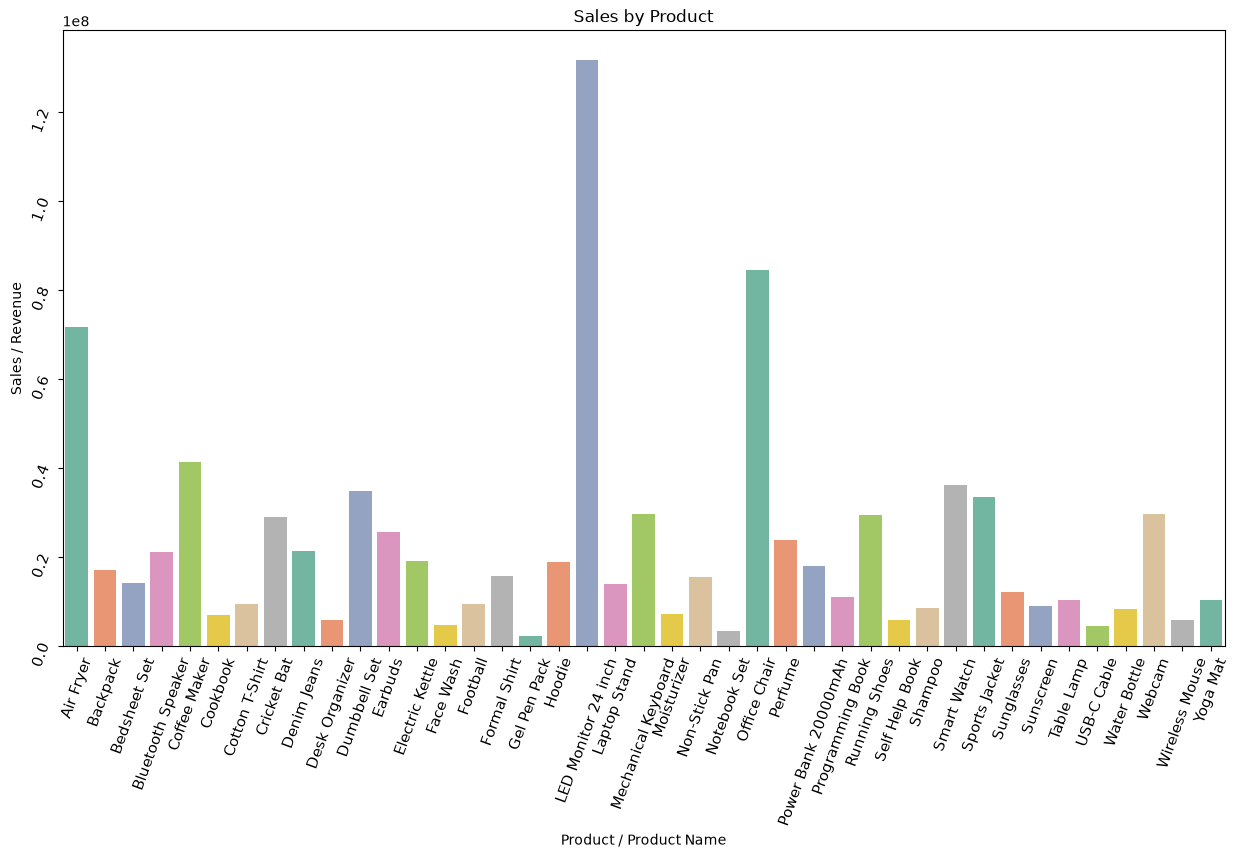

In [95]:
plt.figure(figsize = (15, 8))
prod_bar = sns.barplot(sales_by_product,
                       x='Product / Product Name',
                       y='Sales / Revenue',
                       palette=sns.color_palette("Set2"))
prod_bar.set_title('Sales by Product')
prod_bar.tick_params(labelsize=11, rotation=70)
plt.show()

# Montly profit sales 

In [96]:
profit_by_month = data.groupby('order month')['Profit'].sum().reset_index()
profit_by_month


,order month,Profit
0,1,3.199279e+07
1,2,2.878427e+07
2,3,3.162901e+07
3,4,3.085061e+07
4,5,3.141956e+07
5,6,3.122320e+07
6,7,3.212413e+07
7,8,3.237415e+07
8,9,3.021786e+07
9,10,2.412079e+07


C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\2383428583.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  prod_line = sns.lineplot(profit_by_month,


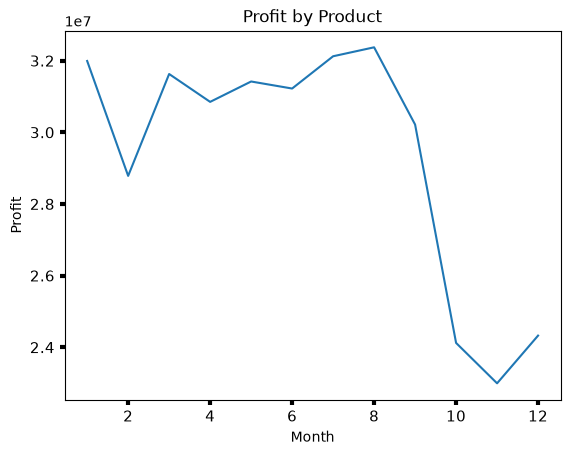

In [97]:
prod_line = sns.lineplot(profit_by_month,
                        x='order month',
                        y='Profit',
                        palette=sns.color_palette("Set2"))

prod_line.set_title('Profit by Product',)
prod_line.set_xlabel('Month')
prod_line.set_ylabel('Profit')
prod_line.tick_params(labelsize=11, width = 3,)
plt.show()

C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\2398155269.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  prod_bar2 =sns.barplot(profit_by_month,
C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\2398155269.py:1: UserWarning: 
The palette list has fewer values (8) than needed (12) and will cycle, which may produce an uninterpretable plot.
  prod_bar2 =sns.barplot(profit_by_month,


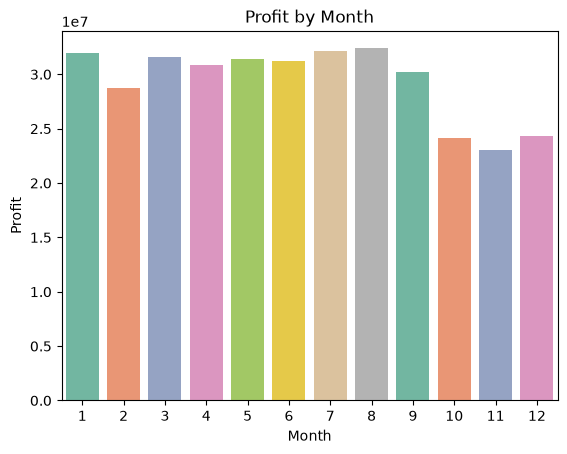

In [98]:
prod_bar2 =sns.barplot(profit_by_month,
                x='order month',
                y='Profit',
                palette=sns.color_palette("Set2"))
prod_bar2.set_title('Profit by Month')
prod_bar2.set_xlabel('Month')
prod_bar2.set_ylabel('Profit')
plt.show()

# Profit by category

In [99]:
data.head()

,Order ID,Order Date,Customer ID,Customer Name,Product ID,Product / Product Name,Category,Quantity,Sales / Revenue,Cost,Profit,Discount,City,State,Region,order month,order year
0,ORD1013864,2023-09-19,C32905,Priya Malhotra,P7002,Programming Book,Books,3,2157.60,1170.0,987.60,0.20,Nagpur,Maharashtra,West,9,2023
1,ORD1041955,2026-03-01,C35163,Aarav Mehta,P3007,Electric Kettle,Home & Kitchen,1,1279.20,850.0,429.20,0.20,Panipat,Haryana,North,3,2026
2,ORD1233639,2025-06-27,C02431,Priya Verma,P6004,Dumbbell Set,Sports,1,2699.10,1650.0,1049.10,0.10,Hubli,Karnataka,South,6,2025
3,ORD1137427,2025-08-14,C21240,Arjun Pal,P1001,Wireless Mouse,Electronics,1,459.08,280.0,179.08,0.08,Mumbai,Maharashtra,West,8,2025
4,ORD1131749,2025-10-04,C21640,Vikas Verma,P5004,Desk Organizer,Stationery,2,848.30,440.0,408.30,0.15,Nizamabad,Telangana,South,10,2025


In [100]:
profit_by_category = data.groupby('Category')['Profit'].sum().reset_index()

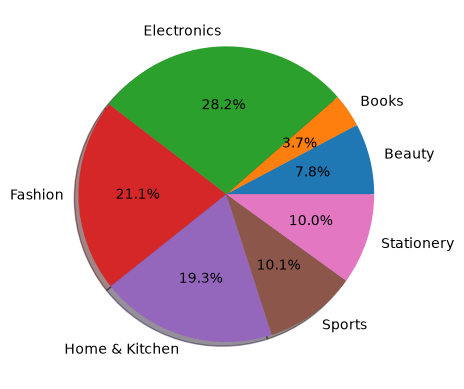

In [101]:
plt.pie(profit_by_category['Profit'],labels=profit_by_category['Category'],autopct='%1.1f%%',shadow=True, startangle=0)
plt.show()

# Profit_by_Prodcut

In [102]:
profit_by_Product = data.groupby(['Product / Product Name'])['Profit'].sum().reset_index()


C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\1896401355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  prod_bar2 =sns.barplot(profit_by_Product,
C:\Users\YOGA\AppData\Local\Temp\ipykernel_10324\1896401355.py:2: UserWarning: 
The palette list has fewer values (8) than needed (41) and will cycle, which may produce an uninterpretable plot.
  prod_bar2 =sns.barplot(profit_by_Product,


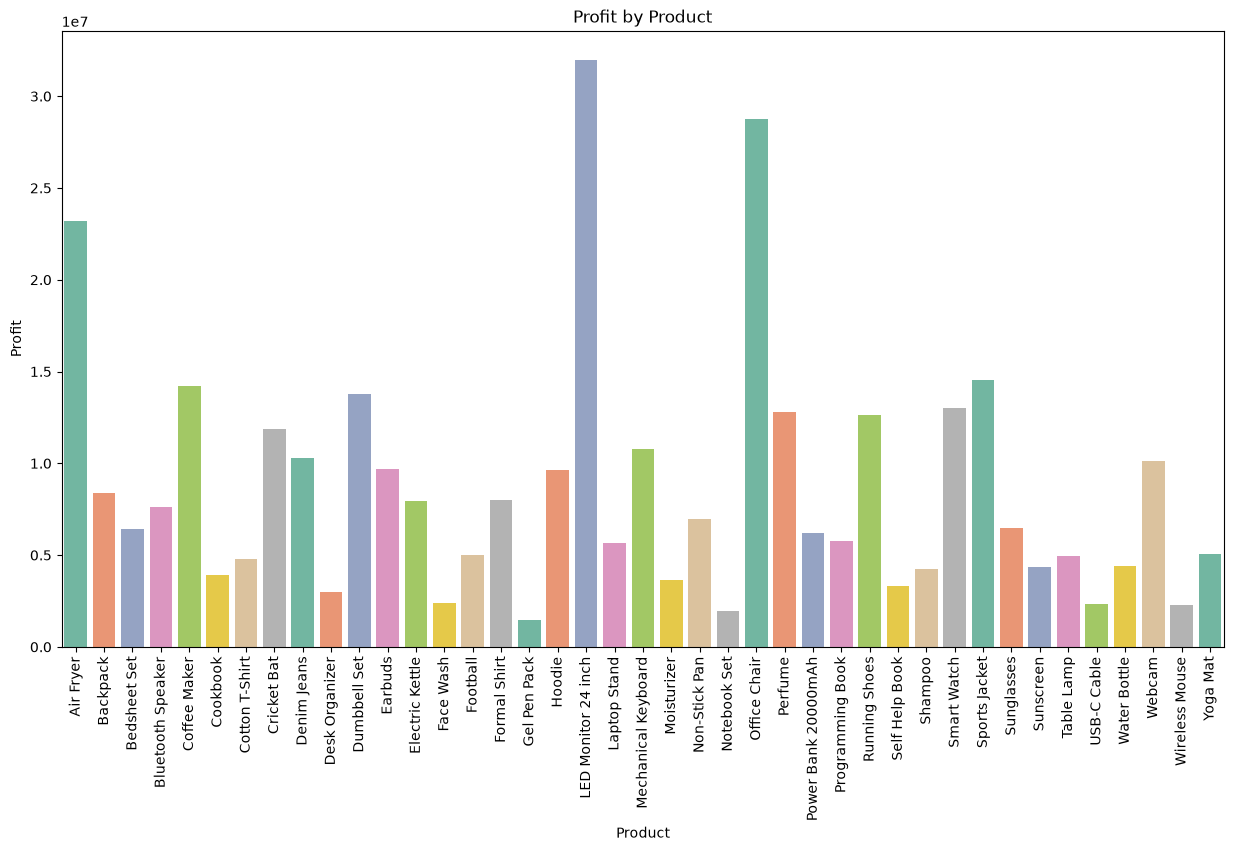

In [104]:
plt.figure(figsize = (15, 8))
prod_bar2 =sns.barplot(profit_by_Product,
                x='Product / Product Name',
                y='Profit',
                palette=sns.color_palette("Set2"))
prod_bar2.set_title('Profit by Product')
prod_bar2.set_xlabel('Product')
prod_bar2.set_ylabel('Profit')
prod_bar2.tick_params(axis='x', labelrotation=90)
plt.show()

# Slaes / Profit Satatewise

In [131]:
sales_profit_by_state = data.groupby(['State']).agg({'Profit':'sum', 'Sales / Revenue' : 'sum'}).reset_index()


In [129]:
state_data = sales_profit_by_state.melt(id_vars='State',
                                         value_vars =['Profit','Sales / Revenue' ],
                                         var_name='metric',
                                         value_name='amount')
state_data.columns

Index(['State', 'metric', 'amount'], dtype='str')

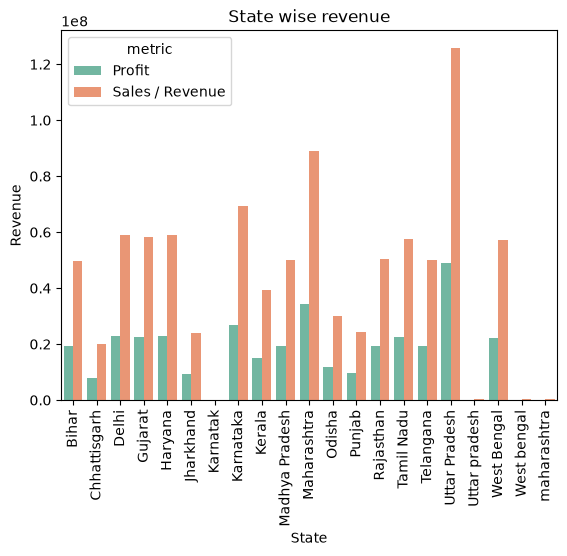

In [130]:
state= sns.barplot(
    
        x=state_data['State'],
        y=state_data['amount'],
        hue= state_data['metric'],
        palette=("Set2"))
state.set_title('State wise revenue')
state.set_xlabel('State')
state.set_ylabel('Revenue')
state.tick_params(axis='x', rotation=90)
plt.show()

# Sales / Profit Ratio

In [134]:
s_P_ratio = data.groupby(['State']).agg({'Sales / Revenue' : 'sum', 'Profit' : 'sum'}).reset_index()
s_P_ratio['sales to profit ratio'] = s_P_ratio['Sales / Revenue'] / s_P_ratio['Profit']
s_P_ratio[['State', 'sales to profit ratio']]

,State,sales to profit ratio
0,Bihar,2.588804
1,Chhattisgarh,2.606041
2,Delhi,2.583622
3,Gujarat,2.574936
4,Haryana,2.589373
5,Jharkhand,2.563886
6,Karnatak,2.486801
7,Karnataka,2.589822
8,Kerala,2.576824
9,Madhya Pradesh,2.597582
